Tenim un dataset provinent d’una enquesta als nostres treballadors i treballadors, i hem de garantir que les dades es processes correctament, tant en format com en llegibilitat.

# Nivell 1

## 1.
Importa com un DataFrame l'arxiu sprint10.xlsx. Assegura't que el fitxer s'importa correctament, amb els noms de columnes que li corresponen, sense manipular l'arxiu original.

Ordena el DataFrame pel país d'origen. En cas d'empat, ordena pel nom de la ciutat.

Mostra les primeres 10 files.

Addicionalment, fes un print on comprovi que el DNI només té valors únics.

In [824]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, date, time, timedelta
import os


In [825]:
arxiu_origen = "sprint10.xlsx"
def import_xlsx(arxiu):
    """
    Importa un fitxer Excel i retorna el DataFrame corresponent.

    Paràmetres:
        arxiu (str): Ruta o nom del fitxer Excel a importar.

    Retorna:
        pandas.DataFrame: Dades llegides amb la primera columna com a índex.
    """

    try:
        importacio = pd.read_excel(arxiu, header = 3, index_col=0 )
        return importacio
    except FileNotFoundError:
        print(f"[ERROR] No s'ha trobat el fitxer: {arxiu}")
    except Exception as e:
        print(f"[ERROR] No s'han pogut importar les dades de '{arxiu}': {e}")


sprint10 = import_xlsx(arxiu_origen)



sprint10

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
0,Inês,Ferreira Silva,16928694K,Portugal,Lisboa,25,2,1953,D,1.144 €,NaN,1.0,Grup B
1,Clara,Sánchez Martínez,27724652S,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A
2,Fatima,Fassi,38141675A,Marroc,Rabat,6,11,2005,A,1.441 €,1.0,NaN,Grup A
3,Khadija,Bennani Bennani,59157262R,Marroc,Rabat,20,1,1995,D,1.944 €,NaN,1.0,Grup B
4,Toni,Sánchez García,69630528M,Espanya,Barcelona,9,8,1999,H,1.043 €,NaN,1.0,Grup A
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Marta,Ferrer Ferrer,25161375F,Espanya,Sevilla,1,6,1951,D,1.216 €,NaN,1.0,Grup B
996,Joan,García,52145541P,Espanya,Sevilla,11,4,1959,H,971 €,NaN,1.0,Grup A
997,Laia,Ferrer Martínez,69760120X,Espanya,Barcelona,11,11,1980,D,682 €,NaN,1.0,Grup A
998,Jordi,García,82947791W,Espanya,Barcelona,23,5,1984,H,1.699 €,1.0,NaN,Grup C


In [826]:
sprint10 = sprint10.sort_values(by = ["País d'origen", "Ciutat"], ignore_index=True)
sprint10


,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
0,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
1,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
2,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
3,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
4,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Emily,Taylor Jones,89577876S,Regne Unit,Manchester,28,3,1958,D,2.033 €,NaN,1.0,Grup B
996,George,Brown Jones,57441590Y,Regne Unit,Manchester,27,12,1979,H,1.130 €,1.0,NaN,Grup A
997,Olivia,Brown Brown,58204038A,Regne Unit,Manchester,28,8,1952,A,1.023 €,NaN,1.0,Grup A
998,Isla,Jones Brown,28367234K,Regne Unit,Manchester,28,3,1999,D,1.197 €,NaN,1.0,Grup A


In [827]:
print("DNI únics:", sprint10["DNI"].is_unique)


DNI únics: True


## 2.
Crea una columna que sigui el nom complet.

In [828]:
sprint10["Nom complet"] = sprint10["Nom"] + " " + sprint10["Cognoms"]
sprint10

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom complet
0,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A,Mia Schneider Fischer
1,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer
2,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider
3,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B,Mia Fischer
4,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D,Jonas Schneider
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Emily,Taylor Jones,89577876S,Regne Unit,Manchester,28,3,1958,D,2.033 €,NaN,1.0,Grup B,Emily Taylor Jones
996,George,Brown Jones,57441590Y,Regne Unit,Manchester,27,12,1979,H,1.130 €,1.0,NaN,Grup A,George Brown Jones
997,Olivia,Brown Brown,58204038A,Regne Unit,Manchester,28,8,1952,A,1.023 €,NaN,1.0,Grup A,Olivia Brown Brown
998,Isla,Jones Brown,28367234K,Regne Unit,Manchester,28,3,1999,D,1.197 €,NaN,1.0,Grup A,Isla Jones Brown


Crea una columna si la persona és nascuda a Espanya o no.

In [829]:
def es_esp(pais):
    """
    Classifica si un país correspon a Espanya.

    Paràmetres:
        pais (str): Nom del país.

    Retorna:
        str: "Si" si el país és Espanya, en cas contrari "No".
    """
    
    if pais == "Espanya":
        return "Si"
    else:
        return "No"

sprint10["Nascut ESP"] = sprint10["País d'origen"].apply(es_esp)


filtre_pais = sprint10["País d'origen"] == "Espanya"
sprint10[filtre_pais]

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom complet,Nascut ESP
92,Clara,Sánchez Martínez,27724652S,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A,Clara Sánchez Martínez,Si
93,Toni,Sánchez García,69630528M,Espanya,Barcelona,9,8,1999,H,1.043 €,NaN,1.0,Grup A,Toni Sánchez García,Si
94,Toni,Martínez,14219925Z,Espanya,Barcelona,16,5,1964,H,891 €,NaN,1.0,Grup A,Toni Martínez,Si
95,Oriol,Sánchez,40695825B,Espanya,Barcelona,27,7,1965,H,1.250 €,NaN,1.0,Grup A,Oriol Sánchez,Si
96,Toni,Castells Romero,74222289K,Espanya,Barcelona,13,4,1961,H,1.438 €,NaN,1.0,Grup B,Toni Castells Romero,Si
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806,Laia,Sánchez,42807414J,Espanya,València,17,7,1967,D,2.255 €,NaN,1.0,Grup C,Laia Sánchez,Si
807,Núria,Martínez Ferrer,38147748A,Espanya,València,4,11,1976,D,1.028 €,NaN,1.0,Grup A,Núria Martínez Ferrer,Si
808,Oriol,Sánchez García,48749091Z,Espanya,València,16,7,1965,H,1.273 €,NaN,1.0,Grup A,Oriol Sánchez García,Si
809,Clara,Romero García,29019539A,Espanya,València,8,2,1989,D,1.246 €,1.0,NaN,Grup A,Clara Romero García,Si


Posa el DNI com a índex del DataFrame (noms de files).


In [830]:
sprint10 = sprint10.set_index("DNI")
sprint10

,Nom,Cognoms,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom complet,Nascut ESP
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,No
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,No
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,No
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B,Mia Fischer,No
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D,Jonas Schneider,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,D,2.033 €,NaN,1.0,Grup B,Emily Taylor Jones,No
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,H,1.130 €,1.0,NaN,Grup A,George Brown Jones,No
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,A,1.023 €,NaN,1.0,Grup A,Olivia Brown Brown,No


Substitueix el nom de les columnes Dia de Naixement, Mes de Naixement i Any de Naixement per Dia, Mes i Any.


In [831]:
sprint10 = sprint10.rename(columns = {"Dia de Naixement":"Dia", "Mes de Naixement":"Mes", "Any de Naixement":"Any"})
sprint10

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom complet,Nascut ESP
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,No
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,No
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,No
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B,Mia Fischer,No
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D,Jonas Schneider,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,D,2.033 €,NaN,1.0,Grup B,Emily Taylor Jones,No
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,H,1.130 €,1.0,NaN,Grup A,George Brown Jones,No
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,A,1.023 €,NaN,1.0,Grup A,Olivia Brown Brown,No


Substitueix H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na).


Mostra tots els canvis que has realitzat en una sola taula.

In [832]:
def renom_sexe(sexe):
    """
    Classifica el codi de sexe en una categoria descriptiva.

    Paràmetres:
        sexe (str): Codi de sexe ('H', 'D', 'A').

    Retorna:
        str o numpy.nan: 'Home', 'Dona', 'Altres' o np.nan si el valor no és vàlid.
    """

    if sexe == "H":
        return "Home"
    elif sexe == "D":
        return "Dona"
    elif sexe == "A":
        return "Altres"
    else:
        return np.nan

sprint10["Gènere"] = sprint10["Gènere"].apply(renom_sexe)
sprint10

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom complet,Nascut ESP
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,No
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,No
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,No
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.0,NaN,Grup B,Mia Fischer,No
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.0,NaN,Grup D,Jonas Schneider,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,NaN,1.0,Grup B,Emily Taylor Jones,No
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,1.0,NaN,Grup A,George Brown Jones,No
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,NaN,1.0,Grup A,Olivia Brown Brown,No


## 3.
Junta les columnes Fills i No Fills en una sola columna, utilitzant el mètode .apply() i definint una funció que resolgui el problema. La columna nova ha de dir-se "Fills" i prendre els valors "Sí" o "No".


In [833]:
def columna_fills(row):
    """
    Classifica si una persona té fills segons les columnes 'Fills' i 'No Fills'.

    Paràmetres:
        row (pandas.Series): Fila amb les columnes 'Fills' i 'No Fills'.

    Retorna:
        str: "Si", "No" o "ERROR" si les dues columnes tenen valor.
    """

    if "Fills" not in row or "No Fills" not in row:
        return "ERROR"

    te_fills = pd.notna(row["Fills"])
    no_te_fills = pd.notna(row["No Fills"])

    if te_fills and no_te_fills:
        return "ERROR"

    if te_fills:
        return "Si"
    else:
        return "No"
    
   
sprint10["Fills"] = sprint10.apply(columna_fills, axis = 1)
sprint10.drop(columns="No Fills")

sprint10


,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom complet,Nascut ESP
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,No,1.0,Grup A,Mia Schneider Fischer,No
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,Si,NaN,Grup B,Laura Schneider Fischer,No
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,No,1.0,Grup B,Lea Schneider Schneider,No
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,Si,NaN,Grup B,Mia Fischer,No
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,Si,NaN,Grup D,Jonas Schneider,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2.033 €,No,1.0,Grup B,Emily Taylor Jones,No
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1.130 €,Si,NaN,Grup A,George Brown Jones,No
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1.023 €,No,1.0,Grup A,Olivia Brown Brown,No


## 4.
Crea una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere.

Ordena la taula en funció del sou mig.

In [834]:
sprint10["Salari mensual"] = (
    sprint10["Salari mensual"]
    .str.replace("€", "", regex = False)
    .str.replace(".", "", regex = False)
    .str.replace(",", ".", regex = False)).str.strip().astype(float)



In [835]:

sprint10_salari = sprint10.groupby("Gènere")["Salari mensual"].agg(["mean", "median", "min", "max"]).round(2)
sprint10_salari

,mean,median,min,max
Gènere,,,,
Altres,1626.59,1545.0,703.0,3175.0
Dona,1469.44,1361.5,665.0,3021.0
Home,1643.25,1531.0,737.0,3356.0


## 5.
Crea una taula resum amb el salari mig per gènere (files) i país d'origen (columnes).

Afegeix-hi les mitjanes als marges de la taula.

(EXTRA): Aplica format condicional a la taula per veure en un color més intens els valors més elevats

In [836]:
sprint10_5 = pd.crosstab(sprint10["Gènere"], sprint10["País d'origen"], margins=True, values = sprint10["Salari mensual"], aggfunc='mean').round(2)
sprint10_5

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,All
Gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,NaN,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
All,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


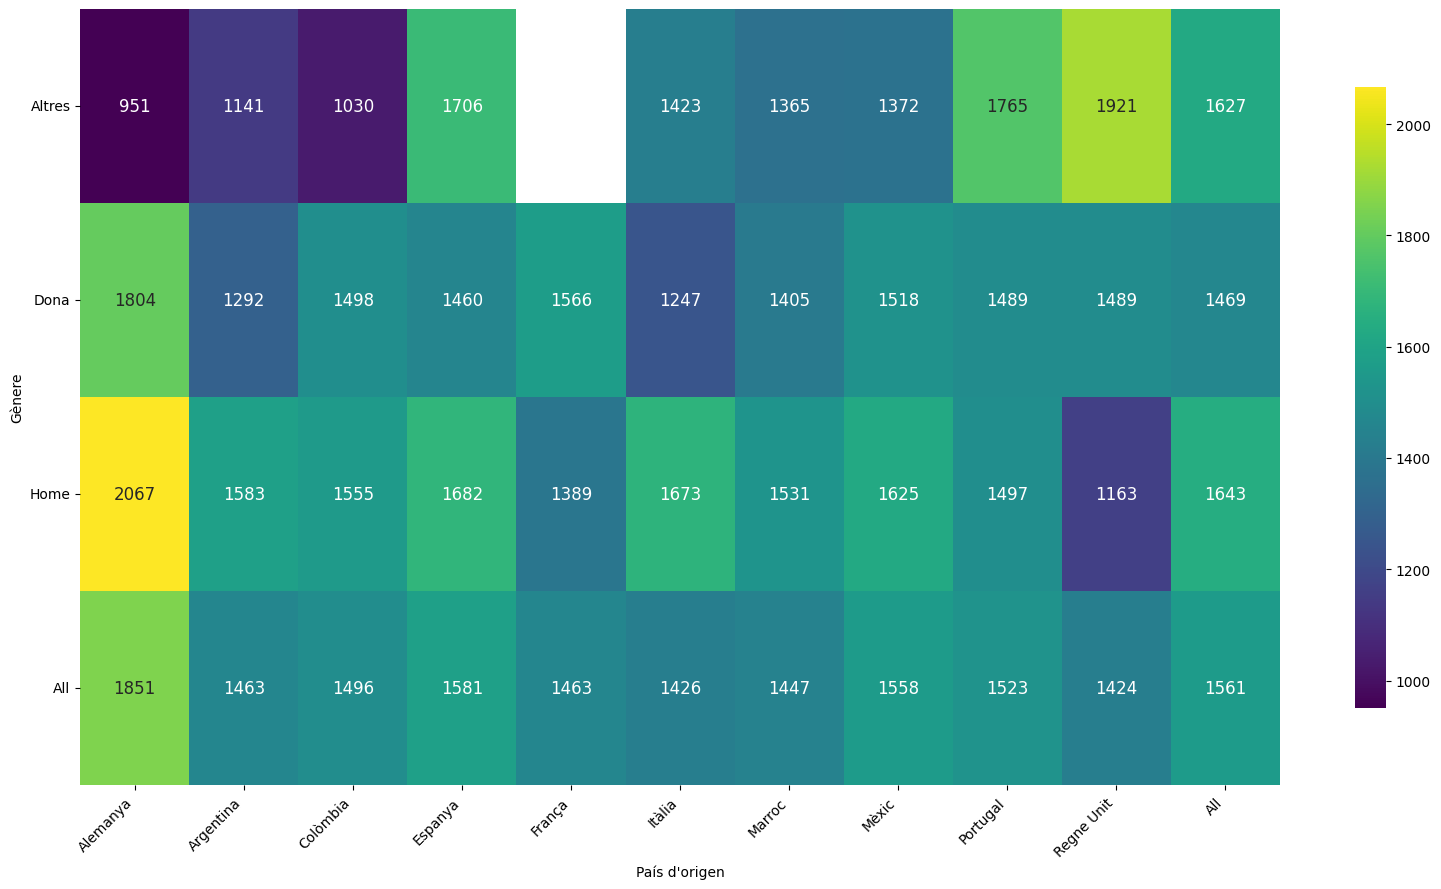

In [837]:
plt.figure(figsize=(16, 9))

sns.heatmap(
    sprint10_5,
    annot=True,
    fmt=".0f",                 # números normals, sense notació científica
    cmap="viridis",
    annot_kws={"size": 12},    # mida dels números
    cbar_kws={"shrink": 0.8}   # fa la barra lateral més petita
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 6.
Crea una columna nova que sigui la data de naixament en format Datetime a partir de les columnes dia, mes i any. Utilitzant aquesta columna crea una funció que donada una data, et calculi l'edat actual a dia d'avui.

Utilitza la funció que acabes de crear per generar una columna nova al DataFrame amb l'edat actual.

In [838]:
sprint10["Data Naixament"] = pd.to_datetime(
    sprint10["Dia"].astype(str) + "-" + sprint10["Mes"].astype(str) + "-" + sprint10["Any"].astype(str), format = "%d-%m-%Y")

def calcul_edad(data):
    """
    Calcula l'edat a partir d'una data de naixement.

    Paràmetres:
        data (datetime o pandas.Timestamp): Data de naixement.

    Retorna:
        int o None: Edat en anys, o None si la data no és vàlida.
    """

    if pd.isna(data):
        return None

    if not hasattr(data, "date"):
        return None

    avui = date.today()
    try:
        return (avui - data.date()).days // 365
    except Exception:
        return None
 

sprint10["Edad"] = sprint10["Data Naixament"].apply(calcul_edad)

sprint10

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom complet,Nascut ESP,Data Naixament,Edad
DNI,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951.0,No,1.0,Grup A,Mia Schneider Fischer,No,1976-10-22,49
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1769.0,Si,NaN,Grup B,Laura Schneider Fischer,No,1958-02-02,68
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2013.0,No,1.0,Grup B,Lea Schneider Schneider,No,2005-10-23,20
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1557.0,Si,NaN,Grup B,Mia Fischer,No,1950-08-11,75
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2754.0,Si,NaN,Grup D,Jonas Schneider,No,1985-11-22,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2033.0,No,1.0,Grup B,Emily Taylor Jones,No,1958-03-28,68
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1130.0,Si,NaN,Grup A,George Brown Jones,No,1979-12-27,46
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1023.0,No,1.0,Grup A,Olivia Brown Brown,No,1952-08-28,73


# Nivell 2

## 1.
Utilitzant el següent DataFrame, adjunta la columna "Increment" al dataframe del nivell anterior.

Actualitza la columna salari en funció dels percentatges que s'adjunten. No modifiquis manualment els increments, escriu codi Python per fer les conversions necessàries.

In [839]:
df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment":

["5%","3,5%","2%","8%"]})

df_increment["Increment"] = (
    df_increment["Increment"]
    .str.replace("%", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float) / 100
)


In [840]:
def increment_salaris(row, increment):
    """
    Aplica l'increment salarial corresponent al grup professional.

    Paràmetres:
        row (pandas.Series): Fila amb les dades del treballador.
        increment (pandas.DataFrame): Taula amb els increments per grup.

    Retorna:
        float: Salari mensual actualitzat amb l'increment aplicat.
    """

    grup = row["Grup Professional"]
    inc = increment.loc[increment["Grup"] == grup, "Increment"].values[0]

    return round((row["Salari mensual"] * (1 + inc)),2)

sprint10["Salari mensual"] = sprint10.apply(
    increment_salaris, axis=1, increment=df_increment
)

sprint10


,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom complet,Nascut ESP,Data Naixament,Edad
DNI,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,998.55,No,1.0,Grup A,Mia Schneider Fischer,No,1976-10-22,49
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1830.92,Si,NaN,Grup B,Laura Schneider Fischer,No,1958-02-02,68
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2083.46,No,1.0,Grup B,Lea Schneider Schneider,No,2005-10-23,20
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1611.50,Si,NaN,Grup B,Mia Fischer,No,1950-08-11,75
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2974.32,Si,NaN,Grup D,Jonas Schneider,No,1985-11-22,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Regne Unit,Manchester,28,3,1958,Dona,2104.15,No,1.0,Grup B,Emily Taylor Jones,No,1958-03-28,68
57441590Y,George,Brown Jones,Regne Unit,Manchester,27,12,1979,Home,1186.50,Si,NaN,Grup A,George Brown Jones,No,1979-12-27,46
58204038A,Olivia,Brown Brown,Regne Unit,Manchester,28,8,1952,Altres,1074.15,No,1.0,Grup A,Olivia Brown Brown,No,1952-08-28,73


## 2.
Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o .csv) les dades de cada Grup Professional.

Per exemple: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...

In [841]:
for grup in sprint10["Grup Professional"].unique():
    df_grup = sprint10[sprint10["Grup Professional"] == grup]
    nom_fitxer = f"dades_{grup.replace(' ', '')}.csv"
    df_grup.to_csv(nom_fitxer, index = False)


Exporta un 5è DataFrame en format .xlsx o .csv que contingui quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.

In [842]:
resum = sprint10.groupby("Grup Professional").agg({
    "Salari mensual": "mean",
    "Edad": "median"
}).round(2)

resum["Nombre Treballadors"] = sprint10.groupby("Grup Professional").size()
resum = resum.rename(columns = {"Salari mensual":"Promig Salari", "Edad":"Promig Edad"})

resum.to_csv("resum_treballadors.csv", index = False)
print("Operació realitzada amb éxit")


Operació realitzada amb éxit


# Nivell 3

El nivell 3 d’aquest sprint és totalment diferent a d’altres sprints que has fet fins ara, ja que són exercicis més abstractes que requereixen barallar-s’hi bastant. No continuen amb el mateix dataset dels nivells anteriors, sinó que et plantegen dues situacions noves totalment diferents entre elles.

## 1.
Crea una funció que prengui un dataframe com a paràmetre d'entrada.

La funció ha de crear (i exportar) un gràfic automàticament per a cada columna del dataframe. Per exemple:

un histograma/boxplot si la variable és numèrica

unes barres dels valors més freqüents si és categòrica

unes barres dels anys més freqüents si la dada està en format data.

La idea és crear una funció que funcioni per qualsevol dataframe, no només amb el que hem treballat fins ara.

Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, iris, penguins o titanic.

Tingues en consideració que en el següent sprint treballaràs exclusivament amb gràfics. L’objectiu d’aquest exercici no és crear gràfics molt elaborats, sinó resoldre una necessitat de manera ràpida i automàtica.

In [843]:
def crear_boxplot(col, serie):
    """
    Genera un histograma i un boxplot per a una columna numèrica.

    Paràmetres:
        col (str): Nom de la columna.
        serie (pandas.Series): Sèrie numèrica amb les dades.

    Retorna:
        None: Desa la imatge a la subcarpeta 'grafiques'.
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.hist(serie, bins=20, color="purple", edgecolor="black")
    ax1.set_title(f"Histograma de {col}")
    ax1.set_xlabel(col)
    ax1.set_ylabel("Freqüència")
    
    ax2.boxplot(serie)
    ax2.set_title(f"Boxplot de {col}")
    ax2.set_ylabel(col)
    
    plt.tight_layout()
    plt.savefig(f"grafiques/graf_{col}_histograma_boxplot.png")
    plt.close()



def crear_barres(col, serie):
    """
    Genera una gràfica de barres amb els valors més freqüents d'una columna categòrica.

    Paràmetres:
        col (str): Nom de la columna.
        serie (pandas.Series): Sèrie categòrica amb les dades.

    Retorna:
        None: Desa la imatge a la subcarpeta 'grafiques'.
    """

    freq = serie.value_counts()
    plt.figure(figsize=(12,4))
    freq.plot(kind="bar", color="orange")
    plt.title(f"Valors més freqüents de {col}")
    plt.xlabel(col)
    plt.ylabel("Comptatge")
    plt.tight_layout()
    plt.savefig(f"grafiques/graf_{col}_freq.png")
    plt.close()


def crear_datetime(col, serie):
    """
    Genera una gràfica de barres amb la freqüència d'anys d'una columna datetime.

    Paràmetres:
        col (str): Nom de la columna.
        serie (pandas.Series): Sèrie de tipus datetime.

    Retorna:
        None: Desa la imatge a la subcarpeta 'grafiques'.
    """

    anys = serie.dt.year.value_counts().sort_index()

    plt.figure(figsize=(12,4))
    anys.plot(kind="bar", color="lightgreen")
    plt.title(f"Freqüència d'anys a {col}")
    plt.xlabel("Any")
    plt.ylabel("Comptatge")
    plt.tight_layout()
    plt.savefig(f"grafiques/graf_{col}_anys.png")
    plt.close()


def crear_grafiques(dataframe):
    """
    Genera gràfiques per a cada columna del DataFrame segons el seu tipus.

    Paràmetres:
        dataframe (pandas.DataFrame): DataFrame amb les dades a representar.

    Retorna:
        None: Desa totes les gràfiques a la subcarpeta 'grafiques'.
    """

    if dataframe.empty:
        print("[ERROR] El dataframe està buit. No es poden generar gràfiques.")
        return


    os.makedirs("grafiques", exist_ok=True)

    for col in dataframe.columns:
        serie = dataframe[col].dropna()

        if serie.empty:
            print(f"[AVÍS] La columna '{col}' està buida. S'omet.")
            continue


        if pd.api.types.is_numeric_dtype(serie):
            crear_boxplot(col, serie)   
        elif pd.api.types.is_datetime64_any_dtype(serie):
            crear_datetime(col, serie)
        else:
            crear_barres(col, serie)
        
    
crear_grafiques(sprint10)
print("Gràfiques generades correctament.")


Gràfiques generades correctament.


## 2.
Carrega l'arxiu matriu_distancies.xlsx a pandas, de manera que els noms de files i els noms de columnes siguin els de les ciutats. Borra "Las Palmas de Gran Canaria" i "Palma" perquè poguem fer el trajecte en cotxe.

Font: Mejores Rutas

Ens interessa visitar totes les ciutats principals d'Espanya recorrent la mínima distància possible.

No cal que ho facis de forma òptima, ens interessa que desenvolupis una solució raonable utilitzant les eines que tens actualment.

Per exemple, una aproximació senzilla (que no òptima) seria anant sempre a la ciutat més propera que no haguem visitat encara

Fes una funció que donada la matriu de distàncies i la ciutat d'origen, faci una proposta de ruta que sigui el més curta possible que puguis, retornant una llista amb l'ordre de visita. Dóna també la distància total recorreguda.

(EXTRA) Des de quina ciutat la ruta seria més curta amb l'algoritme plantejat

In [844]:
matriu_distancies = pd.read_excel(r"matriu_distancies.xlsx", index_col=0)
matriu_distancies.drop(["Palma", "Las Palmas de Gran Canaria"], axis=1, inplace=True)
matriu_distancies.drop(["Palma", "Las Palmas de Gran Canaria"], axis=0, inplace=True)

matriu_distancies

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0
Córdoba,711.0,421.0,121.0,535.0,133.0,320.0,618.0,379.0,NaN,419.0,589.0,634.0,704.0
Valladolid,576.0,441.0,486.0,320.0,549.0,510.0,232.0,515.0,419.0,NaN,337.0,224.0,570.0


In [845]:
def ruta(dataframe, origen):
    """
    Calcula una ruta seguint el criteri de visitar sempre la ciutat més propera
    des d'una ciutat d'origen.

    Paràmetres:
        dataframe (pandas.DataFrame): Matriu de distàncies entre ciutats.
        origen (str): Ciutat d'inici de la ruta.

    Retorna:
        tuple: (llista_ruta, distancia_total)
            - llista_ruta (list): Ordre de ciutats visitades.
            - distancia_total (float): Distància total recorreguda.
    """

    ciutats_restants = list(dataframe.columns)
    ruta = [origen]
    ciutat_actual = origen
    distancia_total = 0

    while len(ciutats_restants) > 1:
        ciutats_restants.remove(ciutat_actual)

        distancies = dataframe.loc[ciutat_actual, ciutats_restants].dropna()
        seguent_ciutat = distancies.idxmin()
        distancia_total += distancies.min()

        ruta.append(seguent_ciutat)
        ciutat_actual = seguent_ciutat

    return ruta, distancia_total


In [846]:
def ruta_optima(dataframe):
    """
    Calcula la millor ruta provant totes les ciutats com a origen.

    Per a cada ciutat del dataframe, calcula la ruta generada per l'algorisme
    greedy (funció ruta) i en registra la distància total. Finalment, selecciona
    la ruta amb la menor distància total.

    Paràmetres:
        dataframe (pandas.DataFrame): Matriu de distàncies entre ciutats.

    Retorna:
        tuple: (ciutat_origen, info_ruta)
            - ciutat_origen (str): Ciutat des d'on s'obté la ruta més curta.
            - info_ruta (dict): Diccionari amb:
                * "ruta": llista de ciutats en l'ordre visitat.
                * "distancia": distància total de la ruta.
    """
    resultats = {}

    for ciutat in dataframe.columns:
        ruta_ciutat, dist = ruta(dataframe, ciutat)
        resultats[ciutat] = {"ruta": ruta_ciutat, "distancia": dist}

    millor = min(resultats, key=lambda c: resultats[c]["distancia"])
    return millor, resultats[millor]


In [847]:
def mostrar_ruta_optima(dataframe):
    """
    Calcula la millor ruta entre totes les ciutats del dataframe i la mostra per pantalla.

    Aquesta funció actua com a capa de presentació: crida la funció `ruta_optima`
    per obtenir la ciutat d'origen amb la ruta més curta i imprimeix l'itinerari
    i la distància total del recorregut.

    Paràmetres:
        dataframe (pandas.DataFrame): Matriu de distàncies entre ciutats.

    Retorna:
        None: La informació es mostra per pantalla.
    """
    
    try:
        origen, info = ruta_optima(dataframe)
    except Exception as e:
        print(f"No s'ha pogut calcular la ruta òptima: {e}")
        return


    print(f"La millor ruta és des de {origen}")
    print(f"Itinerari: {info['ruta']}")
    print(f"Distància total: {info['distancia']} km")


mostrar_ruta_optima(matriu_distancies)

La millor ruta és des de Barcelona
Itinerari: ['Barcelona', 'Hospitalet de Llobregat', 'Zaragoza', 'Valencia', 'Alicante', 'Murcia', 'Córdoba', 'Sevilla', 'Málaga', 'Valladolid', 'Gijón', 'Bilbao', 'Vigo']
Distància total: 2778.0 km
